# DeepFake Detective — CNN Ensemble Training & Comparison

DeepFake Detective — Notebook 1: Multi-Model Training & Comparison
Models : LeNet · AlexNet · VGG16 · ResNet50
Dataset: 140k Real and Fake Faces (FFHQ + StyleGAN)
Runtime: Runtime → Change runtime type → T4 GPU

### Imports

In [9]:
import os, io, random, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
from PIL import Image

matplotlib.rcParams['figure.dpi'] = 130
warnings.filterwarnings('ignore')

# Fix all random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Configuration

In [10]:
BASE_DIR = '/kaggle/input/datasets/retard08/df-dataset/real_vs_fake/real-vs-fake'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
OUTPUT_DIR = '/kaggle/working/deepfake_results'

for sub in ('models', 'plots', 'metrics'):
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

# Verify dataset paths exist before doing any work
for name, path in [('TRAIN', TRAIN_DIR), ('VALID', VALID_DIR), ('TEST', TEST_DIR)]:
    assert os.path.isdir(path), f'{name} not found at {path}'
    print(f'  {name}: OK')

BATCH_SIZE_SM = 128   # LeNet, AlexNet (64×64)
BATCH_SIZE_LG = 64   # VGG16, ResNet50 (224×224)
EPOCHS        = 3   # EarlyStopping patience=5 will cut this short if needed

COLORS = ['#4a90d9', '#e8854a', '#4ac97e', '#d94a7a']
print('\nConfig OK — outputs:', OUTPUT_DIR)

  TRAIN: OK
  VALID: OK
  TEST: OK

Config OK — outputs: /kaggle/working/deepfake_results


### JPEG augmentation helper

In [11]:
# Applied only to the training generator to simulate real-world recompression.
# Uses a fixed local RNG so results are reproducible when combined with SEED.
_jpeg_rng = np.random.RandomState(SEED)

def random_jpeg_compress(img):
    """Round-trip JPEG compression on float32 [0,1] RGB arrays."""
    # Ensure 3-channel; skip silently if shape is unexpected
    if img.ndim != 3 or img.shape[2] != 3:
        return img
    quality  = int(_jpeg_rng.randint(50, 95))
    pil_img  = Image.fromarray((img * 255).astype(np.uint8), mode='RGB')
    buf      = io.BytesIO()
    pil_img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return np.array(Image.open(buf), dtype=np.float32) / 255.0

### Data generators

In [12]:
# Three SEPARATE datagen objects:
#   train_datagen — augmentation + JPEG (train/ only)
#   clean_datagen — rescale only        (valid/ and test/)
# class_indices will be {'fake': 0, 'real': 1} (alphabetical — verified below)

def make_generators(img_size, batch_size):
    train_datagen = ImageDataGenerator(
        rescale             = 1./255,
        horizontal_flip     = True,
        rotation_range      = 15,
        zoom_range          = 0.15,
        brightness_range    = [0.7, 1.3],
        width_shift_range   = 0.1,
        height_shift_range  = 0.1,
        preprocessing_function = random_jpeg_compress,
    )
    clean_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    val_gen = clean_datagen.flow_from_directory(
        VALID_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=False, seed=SEED,
    )
    test_gen = clean_datagen.flow_from_directory(
        TEST_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=False, seed=SEED,
    )

    # Verify that label mapping is consistent and as expected
    assert train_gen.class_indices == {'fake': 0, 'real': 1}, \
        f'Unexpected class mapping: {train_gen.class_indices}'

    print(f'  img={img_size} batch={batch_size} | '
          f'train={train_gen.samples} val={val_gen.samples} test={test_gen.samples}')
    print(f'  classes: {train_gen.class_indices}')
    return train_gen, val_gen, test_gen

print('Generator factory ready.')

Generator factory ready.


### Model definitions

In [13]:
def build_lenet(input_shape=(64, 64, 3)):
    # Classic LeNet with ReLU (replaces tanh for better gradient flow)
    return models.Sequential([
        layers.Conv2D(6,  5, activation='relu', padding='same', input_shape=input_shape),
        layers.AveragePooling2D(2, 2),
        layers.Conv2D(16, 5, activation='relu'),
        layers.AveragePooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(84,  activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1,   activation='sigmoid'),
    ], name='LeNet')


def build_alexnet(input_shape=(64, 64, 3)):
    # AlexNet-inspired; dense layers reduced to 512/256 to limit overfitting
    return models.Sequential([
        layers.Conv2D(96,  3, activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(384, 3, activation='relu', padding='same'),
        layers.Conv2D(384, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1,   activation='sigmoid'),
    ], name='AlexNet')


def build_vgg16(input_shape=(224, 224, 3)):
    # Unfreeze last 8 layers (one full conv block) — consistent depth with ResNet50
    base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-8:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1,   activation='sigmoid')(x)
    return models.Model(base.input, x, name='VGG16')


def build_resnet50(input_shape=(224, 224, 3)):
    # Unfreeze last 10 layers (last residual block)
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-10:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1,   activation='sigmoid')(x)
    return models.Model(base.input, x, name='ResNet50')

print('All model builders defined.')

All model builders defined.


### Training pipeline

In [14]:
def get_callbacks(model_name):
    save_path = os.path.join(OUTPUT_DIR, 'models', f'{model_name}_best.keras')
    return [
        ModelCheckpoint(
            save_path, monitor='val_accuracy',
            save_best_only=True, verbose=1,
        ),
        EarlyStopping(
            monitor='val_accuracy', patience=2,
            restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=2, min_lr=1e-7, verbose=1,
        ),
    ]

def train_model(model, train_gen, val_gen, model_name, lr=1e-4):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name} | LR={lr} | Max epochs={EPOCHS}')
    print(f'{"="*60}')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    model.summary()
    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_gen) // 2,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_name),
    )
    hist_path = os.path.join(OUTPUT_DIR, 'metrics', f'{model_name}_history.pkl')
    with open(hist_path, 'wb') as f:
        pickle.dump(history.history, f)
    print(f'  History saved: {hist_path}')
    return history

print('Training pipeline ready.')

Training pipeline ready.


In [20]:
def make_generators(img_size, batch_size):
    train_datagen = ImageDataGenerator(
        rescale             = 1./255,
        horizontal_flip     = True,
        rotation_range      = 15,
        zoom_range          = 0.15,
        brightness_range    = [0.7, 1.3],
        width_shift_range   = 0.1,
        height_shift_range  = 0.1,
        preprocessing_function = random_jpeg_compress,
    )
    clean_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    val_gen = clean_datagen.flow_from_directory(
        VALID_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    test_gen = clean_datagen.flow_from_directory(
        TEST_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )

    assert train_gen.class_indices == {'fake': 0, 'real': 1}, \
        f'Unexpected class mapping: {train_gen.class_indices}'

    print(f'  img={img_size} batch={batch_size} | '
          f'train={train_gen.samples} val={val_gen.samples} test={test_gen.samples}')
    print(f'  classes: {train_gen.class_indices}')
    return train_gen, val_gen, test_gen

print('Generator factory ready.')

Generator factory ready.


### Build generators

In [21]:
print('Building 64×64 generators...')
train_64, val_64, test_64 = make_generators((64, 64), BATCH_SIZE_SM)

print('Building 224×224 generators...')
train_224, val_224, test_224 = make_generators((224, 224), BATCH_SIZE_LG)

Building 64×64 generators...
Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
  img=(64, 64) batch=128 | train=100000 val=20000 test=20000
  classes: {'fake': 0, 'real': 1}
Building 224×224 generators...
Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
  img=(224, 224) batch=64 | train=100000 val=20000 test=20000
  classes: {'fake': 0, 'real': 1}


### Train all models (each model is isolated — safe to re-run)

In [16]:
# LeNet — lr=1e-4 (same as others; ReLU no longer needs a boosted LR)
lenet        = build_lenet((64, 64, 3))
lenet_hist   = train_model(lenet, train_64, val_64, 'LeNet', lr=1e-4)

# AlexNet
alexnet      = build_alexnet((64, 64, 3))
alexnet_hist = train_model(alexnet, train_64, val_64, 'AlexNet', lr=1e-4)




  Training: LeNet | LR=0.0001 | Max epochs=3


Model: "LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 32, 32, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │       376,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,561 (1.49 MB)

 Trainable params: 389,561 (1.49 MB)

...

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 13,110,785 (50.01 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5030 - loss: 0.7008
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/deepfake_results/models/VGG16_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 979s 1s/step - accuracy: 0.5030 - loss: 0.7008 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 2/3
232/781 ━━━━━━━━━━━━━━━━━━━━ 9:46 1s/step - accuracy: 0.4986 - loss: 0.6932

KeyboardInterrupt: 

In [22]:
train_64, val_64, test_64 = make_generators((64, 64), BATCH_SIZE_SM)
train_224, val_224, test_224 = make_generators((224, 224), BATCH_SIZE_LG)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
  img=(64, 64) batch=128 | train=100000 val=20000 test=20000
  classes: {'fake': 0, 'real': 1}
Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
  img=(224, 224) batch=64 | train=100000 val=20000 test=20000
  classes: {'fake': 0, 'real': 1}


In [27]:
import numpy as np

# Check a batch from train generator
batch_x, batch_y = next(train_224)
print("Train labels:", np.unique(batch_y, return_counts=True))

# Check a batch from val generator  
batch_x, batch_y = next(val_224)
print("Val labels:", np.unique(batch_y, return_counts=True))

# Check what VGG16 predicts on a raw batch
vgg_test = build_vgg16((224, 224, 3))
batch_x, batch_y = next(val_224)
preds = vgg_test.predict(batch_x, verbose=0)
print("Raw predictions:", preds[:10].flatten())
print("True labels:", batch_y[:10])

Train labels: (array([0., 1.], dtype=float32), array([24, 40]))
Val labels: (array([0., 1.], dtype=float32), array([23, 41]))
Raw predictions: [0.34199494 0.3163265  0.33633578 0.33019587 0.3295322  0.32647076
 0.31028095 0.33805048 0.34553504 0.31151202]
True labels: [0. 1. 0. 0. 1. 1. 0. 0. 0. 1.]


In [28]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

In [30]:
def make_generators_large(img_size, batch_size, preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.15,
        brightness_range=[0.7, 1.3],
        width_shift_range=0.1,
        height_shift_range=0.1,
    )
    clean_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    val_gen = clean_datagen.flow_from_directory(
        VALID_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    test_gen = clean_datagen.flow_from_directory(
        TEST_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='binary', shuffle=True, seed=SEED,
    )
    return train_gen, val_gen, test_gen

In [31]:
train_224_vgg, val_224_vgg, test_224_vgg = make_generators_large((224,224), BATCH_SIZE_LG, vgg_preprocess)
train_224_res, val_224_res, test_224_res = make_generators_large((224,224), BATCH_SIZE_LG, resnet_preprocess)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [32]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Build VGG16-specific generators
vgg_clean = ImageDataGenerator(preprocessing_function=vgg_preprocess)
vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
)

train_224_vgg = vgg_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)
val_224_vgg = vgg_clean.flow_from_directory(
    VALID_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)
test_224_vgg = vgg_clean.flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)

# Train
vgg = build_vgg16((224, 224, 3))
vgg_hist = train_model(vgg, train_224_vgg, val_224_vgg, 'VGG16', lr=1e-4)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.

  Training: VGG16 | LR=0.0001 | Max epochs=3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 13,110,785 (50.01 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5677 - loss: 0.6824
Epoch 1: val_accuracy improved from -inf to 0.85350, saving model to /kaggle/working/deepfake_results/models/VGG16_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 899s 1s/step - accuracy: 0.5678 - loss: 0.6823 - val_accuracy: 0.8535 - val_loss: 0.3381 - learning_rate: 1.0000e-04
Epoch 2/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8557 - loss: 0.3361
Epoch 2: val_accuracy improved from 0.85350 to 0.94820, saving model to /kaggle/working/deepfake_results/models/VGG16_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 946s 1s/step - accuracy: 0.8558 - loss: 0.3360 - val_accuracy: 0.9482 - val_loss: 0.1398 - learning_rate: 1.0000e-04
Epoch 3/3
  1/781 ━━━━━━━━━━━━━━━━━━━━ 5:43 440ms/step - accuracy: 0.9531 - loss: 0.1409
Epoch 3: val_accuracy did not improve from 0.94820
781/781 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.9531 - loss: 0.1409 - val_accuracy: 0.9338 - val_loss: 0.1730 - learning_rate: 1.0000e-

In [33]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_clean = ImageDataGenerator(preprocessing_function=resnet_preprocess)
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
)

train_224_res = resnet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)
val_224_res = resnet_clean.flow_from_directory(
    VALID_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)
test_224_res = resnet_clean.flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=True, seed=SEED,
)

resnet = build_resnet50((224, 224, 3))
resnet_hist = train_model(resnet, train_224_res, val_224_res, 'ResNet50', lr=1e-4)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.

  Training: ResNet50 | LR=0.0001 | Max epochs=3


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_11[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 4,990,465 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.7709 - loss: 0.4666
Epoch 1: val_accuracy improved from -inf to 0.89835, saving model to /kaggle/working/deepfake_results/models/ResNet50_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 891s 1s/step - accuracy: 0.7710 - loss: 0.4665 - val_accuracy: 0.8984 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 2/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9103 - loss: 0.2193
Epoch 2: val_accuracy improved from 0.89835 to 0.93675, saving model to /kaggle/working/deepfake_results/models/ResNet50_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 919s 1s/step - accuracy: 0.9103 - loss: 0.2193 - val_accuracy: 0.9367 - val_loss: 0.1593 - learning_rate: 1.0000e-04
Epoch 3/3
  1/781 ━━━━━━━━━━━━━━━━━━━━ 2:12 170ms/step - accuracy: 0.9219 - loss: 0.1693
Epoch 3: val_accuracy improved from 0.93675 to 0.93700, saving model to /kaggle/working/deepfake_results/models/ResNet50_best.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 72s 93ms/step - accuracy: 

### Evaluate on test set

In [34]:
# Models are loaded from disk so this cell is safe after a runtime reset.
# Predictions are truncated to len(y_true) to handle non-divisible batch sizes.

# Rebuild test generators with shuffle=False for correct evaluation
vgg_clean_eval = ImageDataGenerator(preprocessing_function=vgg_preprocess)
resnet_clean_eval = ImageDataGenerator(preprocessing_function=resnet_preprocess)

test_64_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=(64,64), batch_size=BATCH_SIZE_SM,
    class_mode='binary', shuffle=False, seed=SEED,
)
test_224_vgg_eval = vgg_clean_eval.flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=False, seed=SEED,
)
test_224_res_eval = resnet_clean_eval.flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=BATCH_SIZE_LG,
    class_mode='binary', shuffle=False, seed=SEED,
)

MODEL_CONFIGS = [
    ('LeNet',    'LeNet_best.keras',    test_64_eval,      64),
    ('AlexNet',  'AlexNet_best.keras',  test_64_eval,      64),
    ('VGG16',    'VGG16_best.keras',    test_224_vgg_eval, 224),
    ('ResNet50', 'ResNet50_best.keras', test_224_res_eval, 224),
]

results = []
for name, fname, test_gen, _ in MODEL_CONFIGS:
    print(f'\nEvaluating {name}...')
    m = load_model(os.path.join(OUTPUT_DIR, 'models', fname))
    test_gen.reset()
    n_true = test_gen.samples
    y_true = test_gen.classes
    y_prob = m.predict(test_gen, verbose=1).flatten()[:n_true]
    y_pred = (y_prob >= 0.5).astype(int)
    report = classification_report(
        y_true, y_pred, target_names=['fake', 'real'], output_dict=True
    )
    auc = roc_auc_score(y_true, y_prob)
    results.append({
        'Model':     name,
        'Accuracy':  round(report['accuracy']                 * 100, 2),
        'Precision': round(report['weighted avg']['precision'] * 100, 2),
        'Recall':    round(report['weighted avg']['recall']    * 100, 2),
        'F1-Score':  round(report['weighted avg']['f1-score']  * 100, 2),
        'AUC-ROC':   round(auc                                * 100, 2),
        'F1-Fake':   round(report['fake']['f1-score']          * 100, 2),
        'F1-Real':   round(report['real']['f1-score']          * 100, 2),
    })
    print(classification_report(y_true, y_pred, target_names=['fake', 'real']))

df = pd.DataFrame(results)
print('\n', df.to_string(index=False))
csv_path = os.path.join(OUTPUT_DIR, 'metrics', 'comparison_table.csv')
df.to_csv(csv_path, index=False)
print('Saved:', csv_path)

Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.

Evaluating LeNet...
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 756ms/step
              precision    recall  f1-score   support

        fake       0.30      0.01      0.01     10000
        real       0.50      0.99      0.66     10000

    accuracy                           0.50     20000
   macro avg       0.40      0.50      0.34     20000
weighted avg       0.40      0.50      0.34     20000


Evaluating AlexNet...
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step
              precision    recall  f1-score   support

        fake       0.54      0.23      0.32     10000
        real       0.51      0.81      0.63     10000

    accuracy                           0.52     20000
   macro avg       0.53      0.52      0.47     20000
weighted avg       0.53      0.52      0.47     20000


Evaluating VGG16...
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 294ms/step
              preci

### Training curves

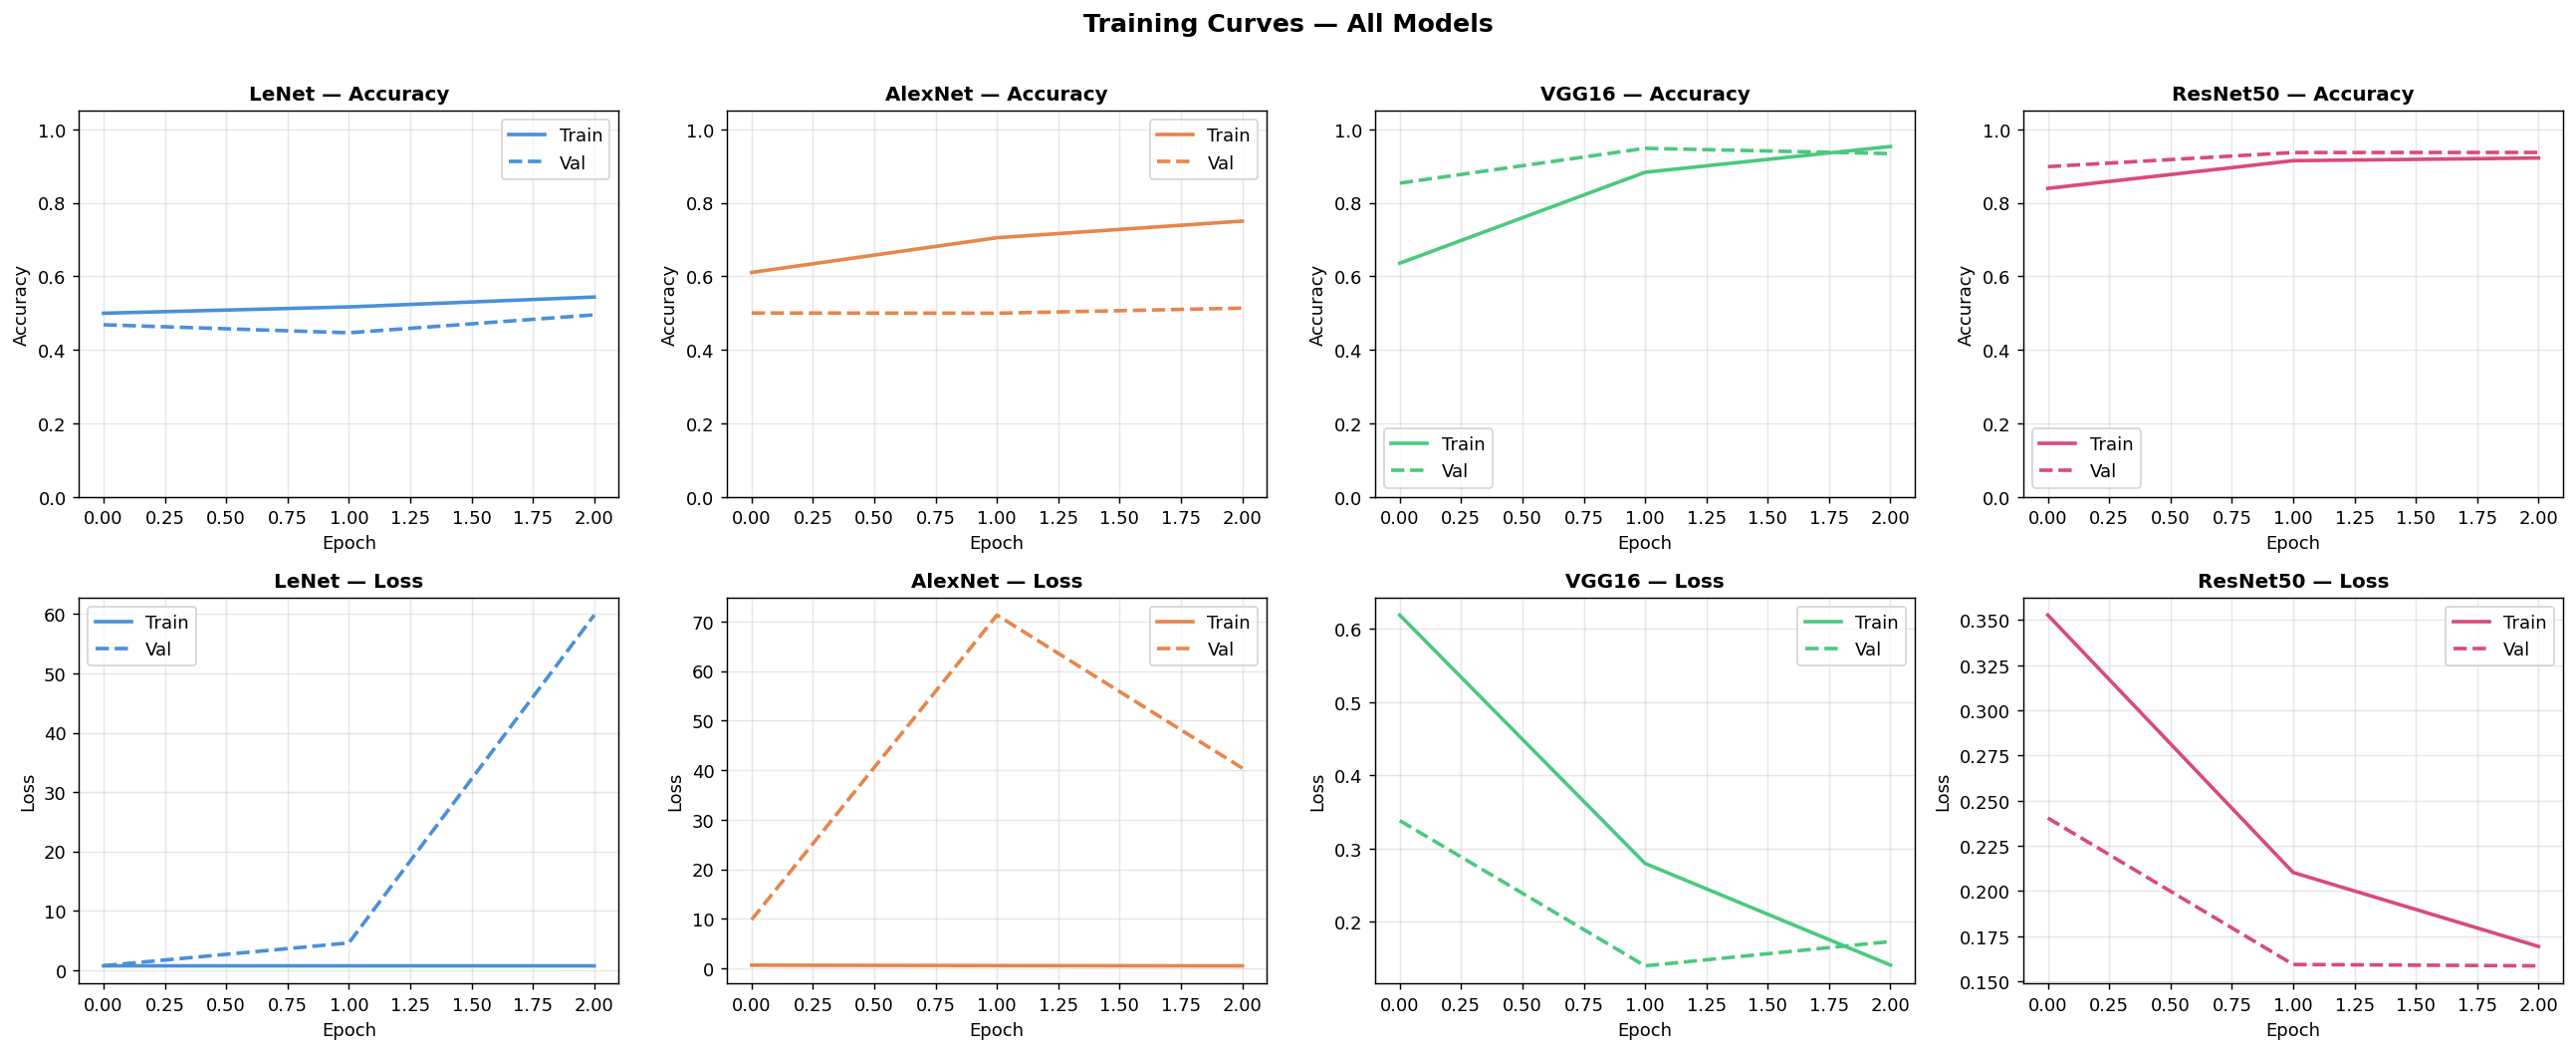

Saved: /kaggle/working/deepfake_results/plots/training_curves.png


In [36]:
def load_history(model_name):
    path = os.path.join(OUTPUT_DIR, 'metrics', f'{model_name}_history.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

histories = {name: load_history(name) for name, *_ in MODEL_CONFIGS}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, (name, hist) in enumerate(histories.items()):
    color = COLORS[idx]
    ax = axes[0][idx]
    ax.plot(hist['accuracy'],     color=color, lw=2, label='Train')
    ax.plot(hist['val_accuracy'], color=color, lw=2, linestyle='--', label='Val')
    ax.set_title(f'{name} — Accuracy', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1][idx]
    ax.plot(hist['loss'],     color=color, lw=2, label='Train')
    ax.plot(hist['val_loss'], color=color, lw=2, linestyle='--', label='Val')
    ax.set_title(f'{name} — Loss', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'plots', 'training_curves.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print('Saved:', path)

### Comparison bar chart

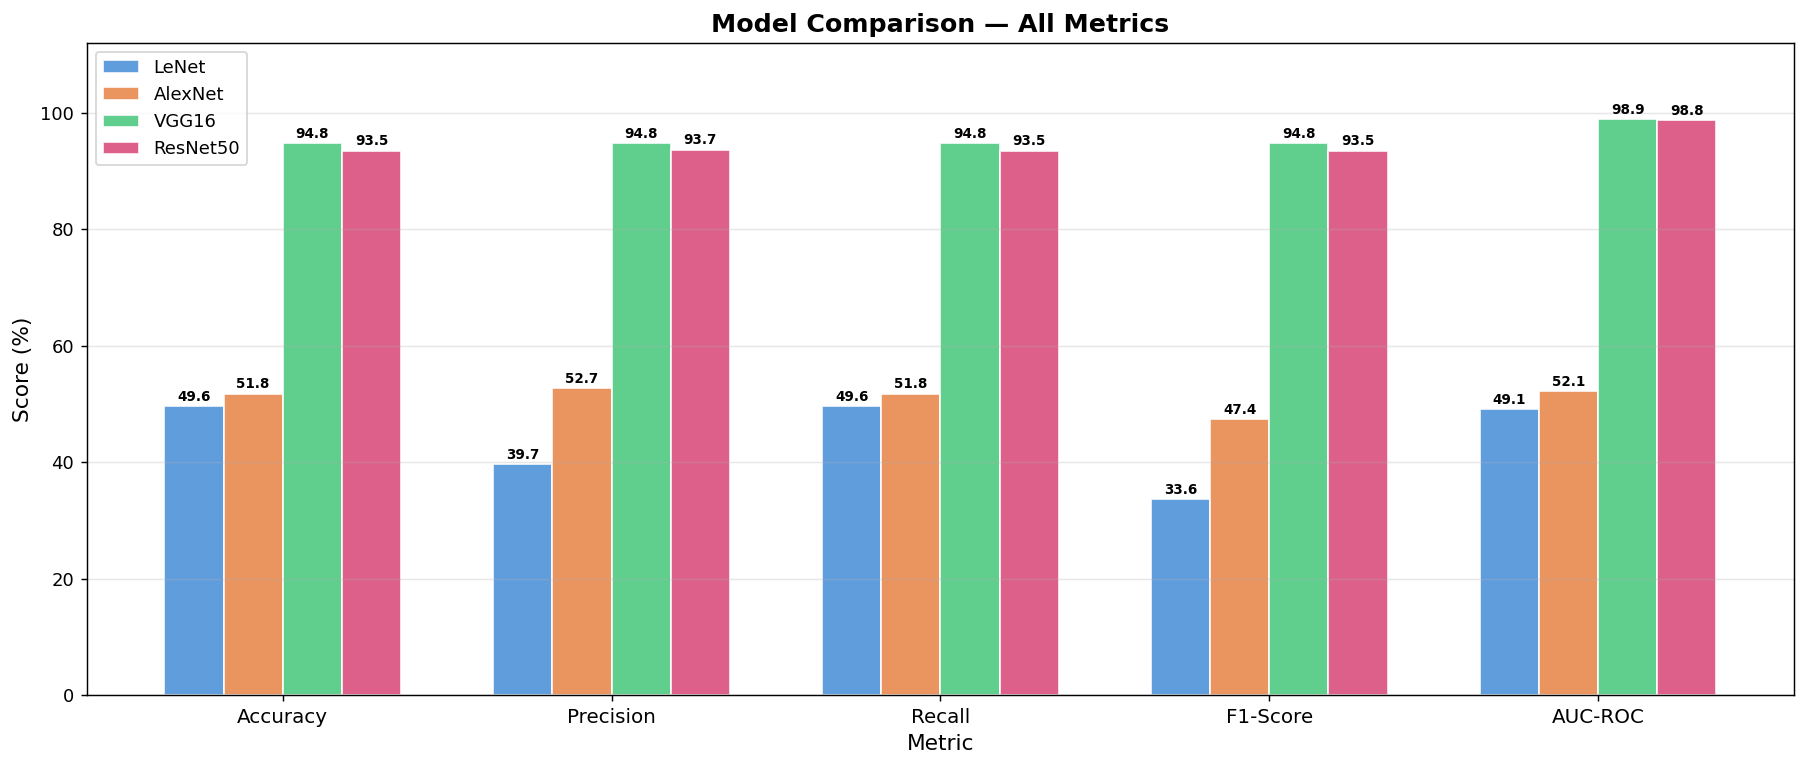

Saved: /kaggle/working/deepfake_results/plots/model_comparison.png


In [37]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'metrics', 'comparison_table.csv'))

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x     = np.arange(len(metric_cols))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(df.iterrows()):
    vals = [row[m] for m in metric_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=row['Model'], color=COLORS[i], alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 112)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'plots', 'model_comparison.png')
plt.savefig(path, dpi=150)
plt.show()
print('Saved:', path)

### Confusion matrices

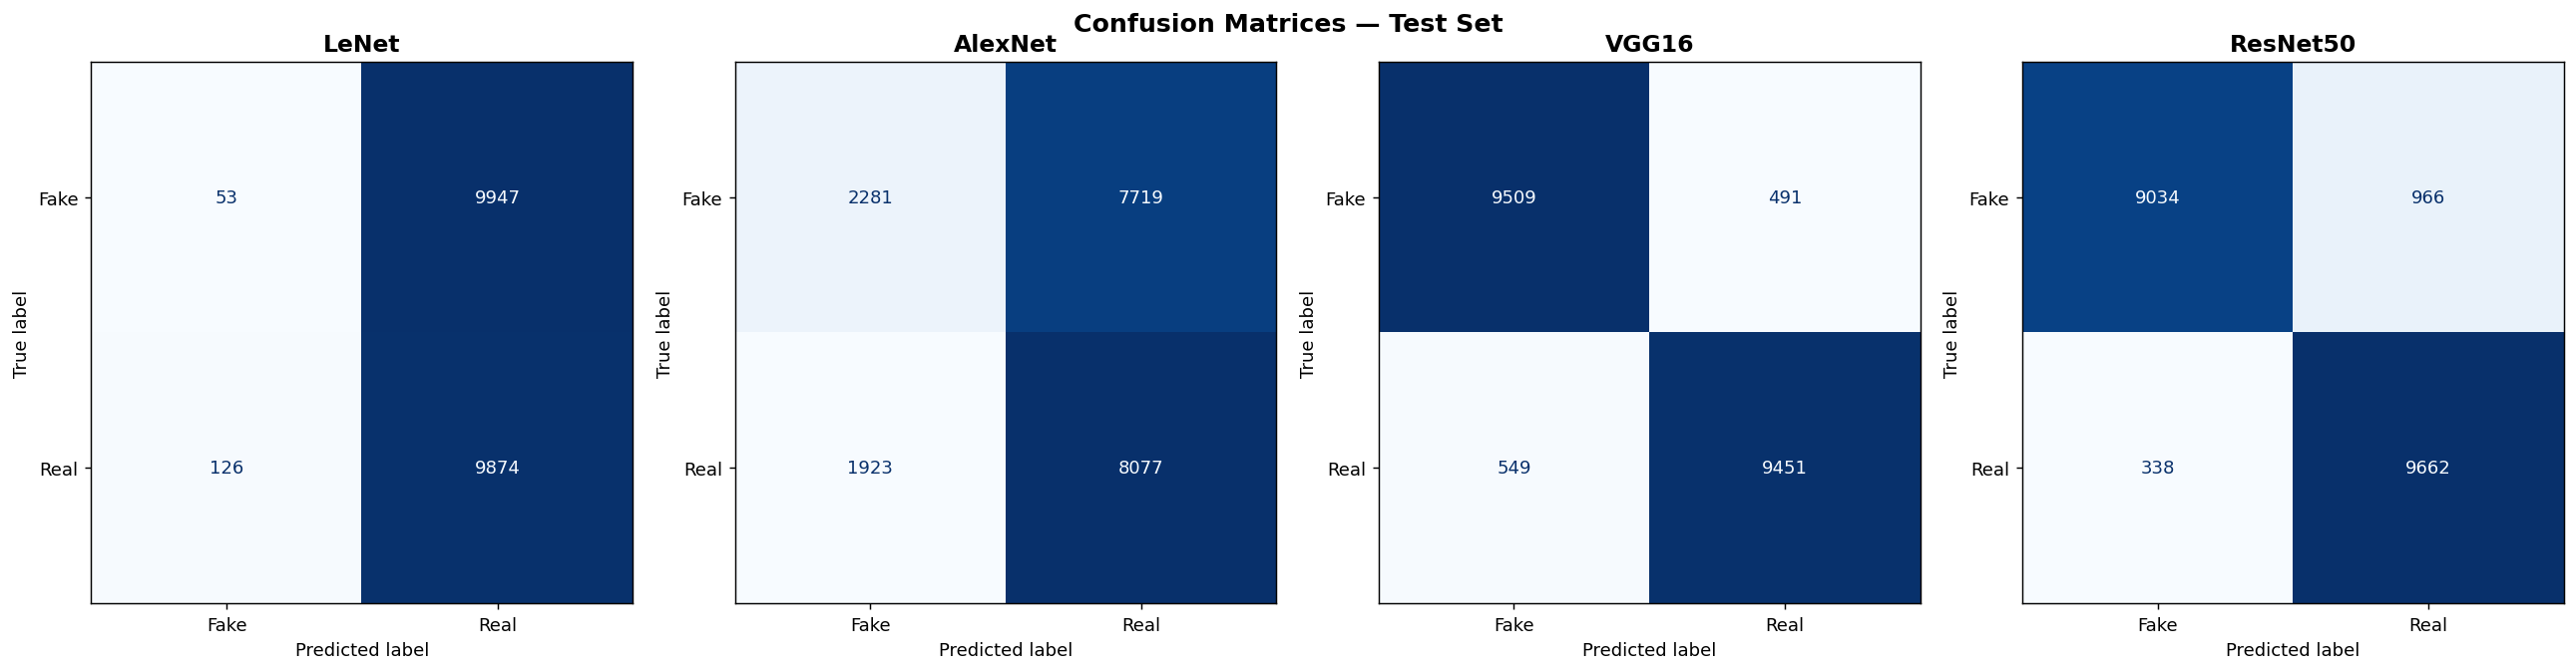

Saved: /kaggle/working/deepfake_results/plots/confusion_matrices.png


In [38]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (name, fname, test_gen, _) in enumerate(MODEL_CONFIGS):
    m = load_model(os.path.join(OUTPUT_DIR, 'models', fname))
    test_gen.reset()
    n_true = test_gen.samples
    y_prob = m.predict(test_gen, verbose=0).flatten()[:n_true]
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'plots', 'confusion_matrices.png')
plt.savefig(path, dpi=150)
plt.show()
print('Saved:', path)

### ROC curves

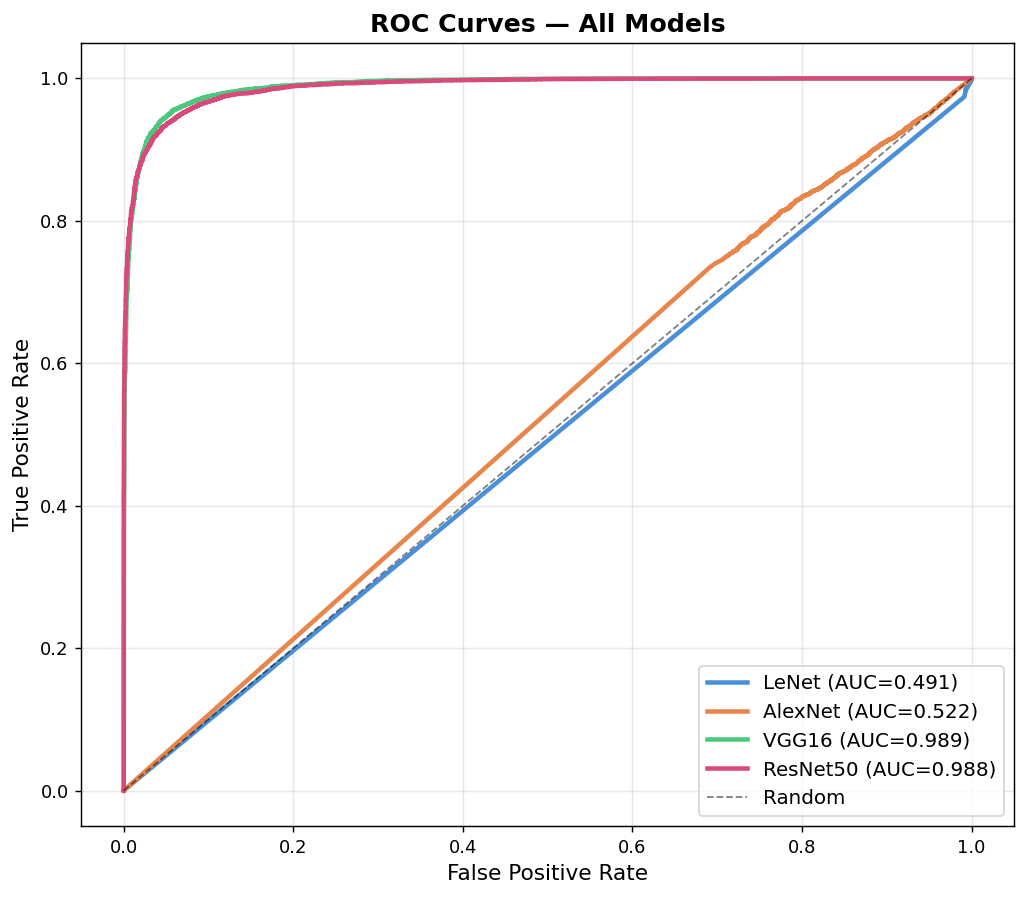

Saved: /kaggle/working/deepfake_results/plots/roc_curves.png


In [39]:
fig, ax = plt.subplots(figsize=(8, 7))
for idx, (name, fname, test_gen, _) in enumerate(MODEL_CONFIGS):
    m = load_model(os.path.join(OUTPUT_DIR, 'models', fname))
    test_gen.reset()
    n_true = test_gen.samples
    y_prob = m.predict(test_gen, verbose=0).flatten()[:n_true]
    y_true = test_gen.classes

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc         = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=COLORS[idx], lw=2.5, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'plots', 'roc_curves.png')
plt.savefig(path, dpi=150)
plt.show()
print('Saved:', path)

### Final summary

In [40]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'metrics', 'comparison_table.csv'))
print('\n' + '=' * 65)
print('  DEEPFAKE DETECTIVE — FINAL MODEL COMPARISON')
print('=' * 65)
print(df.to_string(index=False))
print('=' * 65)
best_f1  = df.loc[df['F1-Score'].idxmax()]
best_auc = df.loc[df['AUC-ROC'].idxmax()]
print(f'\n  Best F1-Score : {best_f1["Model"]}  ({best_f1["F1-Score"]}%)')
print(f'  Best AUC-ROC  : {best_auc["Model"]}  ({best_auc["AUC-ROC"]}%)')
print(f'\n  All outputs saved to: {OUTPUT_DIR}')


  DEEPFAKE DETECTIVE — FINAL MODEL COMPARISON
   Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  F1-Fake  F1-Real
   LeNet     49.63      39.71   49.63     33.63    49.14     1.04    66.22
 AlexNet     51.79      52.70   51.79     47.37    52.15    32.12    62.62
   VGG16     94.80      94.80   94.80     94.80    98.87    94.82    94.78
ResNet50     93.48      93.65   93.48     93.47    98.76    93.27    93.68

  Best F1-Score : VGG16  (94.8%)
  Best AUC-ROC  : VGG16  (98.87%)

  All outputs saved to: /kaggle/working/deepfake_results
